In [1]:
import os
os.environ["NUMBA_CACHE_DIR"] = "/nemo/lab/briscoej/home/users/boeziog/python_cache/numba"
os.environ["XDG_CACHE_HOME"] = "/nemo/lab/briscoej/home/users/boeziog/python_cache"
os.environ["MPLCONFIGDIR"] = "/nemo/lab/briscoej/home/users/boeziog/python_cache/matplotlib"

In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sclitr as sl
import igraph
sc.set_figure_params(dpi=100)
sns.set_style("ticks")

In [8]:
# ─── PARAMETERS — edit before running ────────────────────────────────────────
target_experiment = ["1-somite", "4-somites", "7-somites"]    # "1-somite", "4-somites", "7-somites"
# annotation_col    = "cell_type_fine"
# annotation_col  = "cell_type_coarse"
annotation_col  = "cell_type_collapsed"   # pre-computed in R, recommended for scLiTr
scvi_rep          = "X_scvi"      # verify with: list(adata.obsm.keys()) after loading

In [9]:
data_path = "/nemo/lab/briscoej/home/users/boeziog/LARRY/"
h5ad_path = os.path.join(data_path, "injHH7-collHH18", "LARRY_NT_integrated_07-09-2025_annotated.h5ad")

figures_output = os.path.join(
    data_path, "LARRY_spinal_cord", "Jupyter_notebooks", "plots", "chicken", "injHH7-collHH18", "scLiTr"
)
os.makedirs(figures_output, exist_ok=True)

def save_plot(plot_name, annotation=None):
    suffix = f"_{annotation}" if annotation is not None else ""
    filename = f"{target_experiment}_{plot_name}{suffix}.pdf"
    save_path = os.path.join(figures_output, filename)
    plt.savefig(save_path, format="pdf", bbox_inches="tight")
    print(f"Saved plot to: {save_path}")

# Build h5ad from R export (run once, skip when h5ad exists)

In [20]:
# ─── RUN ONCE: rebuild h5ad from R export ────────────────────────────────────
# Skip this cell once h5ad_path already exists on NEMO.

import anndata as ad
import scipy.io

export_dir = "/nemo/lab/briscoej/home/users/boeziog/LARRY/injHH7-collHH18/h5ad_export"

counts   = scipy.io.mmread(os.path.join(export_dir, "counts.mtx")).tocsr().T  # → cells × genes
genes    = pd.read_csv(os.path.join(export_dir, "genes.txt"),    header=None)[0].tolist()
barcodes = pd.read_csv(os.path.join(export_dir, "barcodes.txt"), header=None)[0].tolist()
meta     = pd.read_csv(os.path.join(export_dir, "metadata.csv"), index_col="index")
scvi_df  = pd.read_csv(os.path.join(export_dir, "X_scvi.csv"),   index_col="index")
umap_df  = pd.read_csv(os.path.join(export_dir, "X_umap.csv"),   index_col="index")

adata_build = ad.AnnData(
    X   = counts,
    obs = meta.reindex(barcodes),
    var = pd.DataFrame(index=genes),
)
adata_build.obsm["X_scvi"] = scvi_df.reindex(barcodes).values.astype("float32")
adata_build.obsm["X_umap"] = umap_df.reindex(barcodes).values.astype("float32")

adata_build.write_h5ad(h5ad_path)
print(f"Saved h5ad → {h5ad_path}")
print(adata_build)
del adata_build

Saved h5ad → /nemo/lab/briscoej/home/users/boeziog/LARRY/Ashley/LARRY_NT_integrated_07-09-2025_annotated.h5ad
AnnData object with n_obs × n_vars = 6263 × 15918
    obs: 'clone', 'somites', 'cell_type_fine', 'cell_type_coarse', 'cell_type_collapsed'
    obsm: 'X_scvi', 'X_umap'


# Load and inspect adata

In [10]:
adata = sc.read_h5ad(h5ad_path)
print(adata)
print("\nobs columns:", adata.obs.columns.tolist())
print("obsm keys:  ", list(adata.obsm.keys()))
print("layers:     ", list(adata.layers.keys()))

AnnData object with n_obs × n_vars = 6263 × 15918
    obs: 'clone', 'somites', 'cell_type_fine', 'cell_type_coarse', 'cell_type_collapsed'
    obsm: 'X_scvi', 'X_umap'

obs columns: ['clone', 'somites', 'cell_type_fine', 'cell_type_coarse', 'cell_type_collapsed']
obsm keys:   ['X_scvi', 'X_umap']
layers:      []


In [11]:
# Rename columns to match scLiTr conventions
adata.obs = adata.obs.rename(columns={
    "exp_clone":   "clone",
    annotation_col: "cell_type",
    "somites":     "experiment",
})
print(adata.obs[["experiment", "cell_type", "clone"]].head())
print("\nexperiment counts:\n", adata.obs["experiment"].value_counts())
print("\ncell_type counts:\n", adata.obs["cell_type"].value_counts())

                   experiment cell_type              clone
index                                                     
AAACCCATCATGCAGT-1  7-somites        MN                NaN
AAACGAAGTGCGCTCA-1  7-somites       dp6                NaN
AAAGAACTCAGAGCGA-1  7-somites       dp1                NaN
AAAGGATAGAGGATGA-1  7-somites       pMN  clone_2_LIB6512A1
AACAGGGCAACTTGGT-1  7-somites       dp6  clone_5_LIB6512A1

experiment counts:
 experiment
4-somites    2937
7-somites    2286
1-somite     1040
Name: count, dtype: int64

cell_type counts:
 cell_type
p0         1029
dp4/5       895
pMN         764
dp6         553
dp1         508
p2          492
MN          410
p1          408
dI4/dI5     176
V3          140
Unclear     135
V0/V1       118
dp3         107
RP           82
dp2          81
FP           79
dI2          78
p3           76
dI1          66
V2           59
Name: count, dtype: int64


In [12]:
adata_full = adata.copy()


# scLiTr analyses

In [13]:
adata = adata_full[adata_full.obs["experiment"].isin(target_experiment)].copy()
print(f"Keeping: {target_experiment}. Cells: {adata.n_obs}")

Keeping: ['1-somite', '4-somites', '7-somites']. Cells: 6263


## Check largest clone

/camp/lab/briscoej/home/users/boeziog/.conda/envs/sclitr_cpu/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


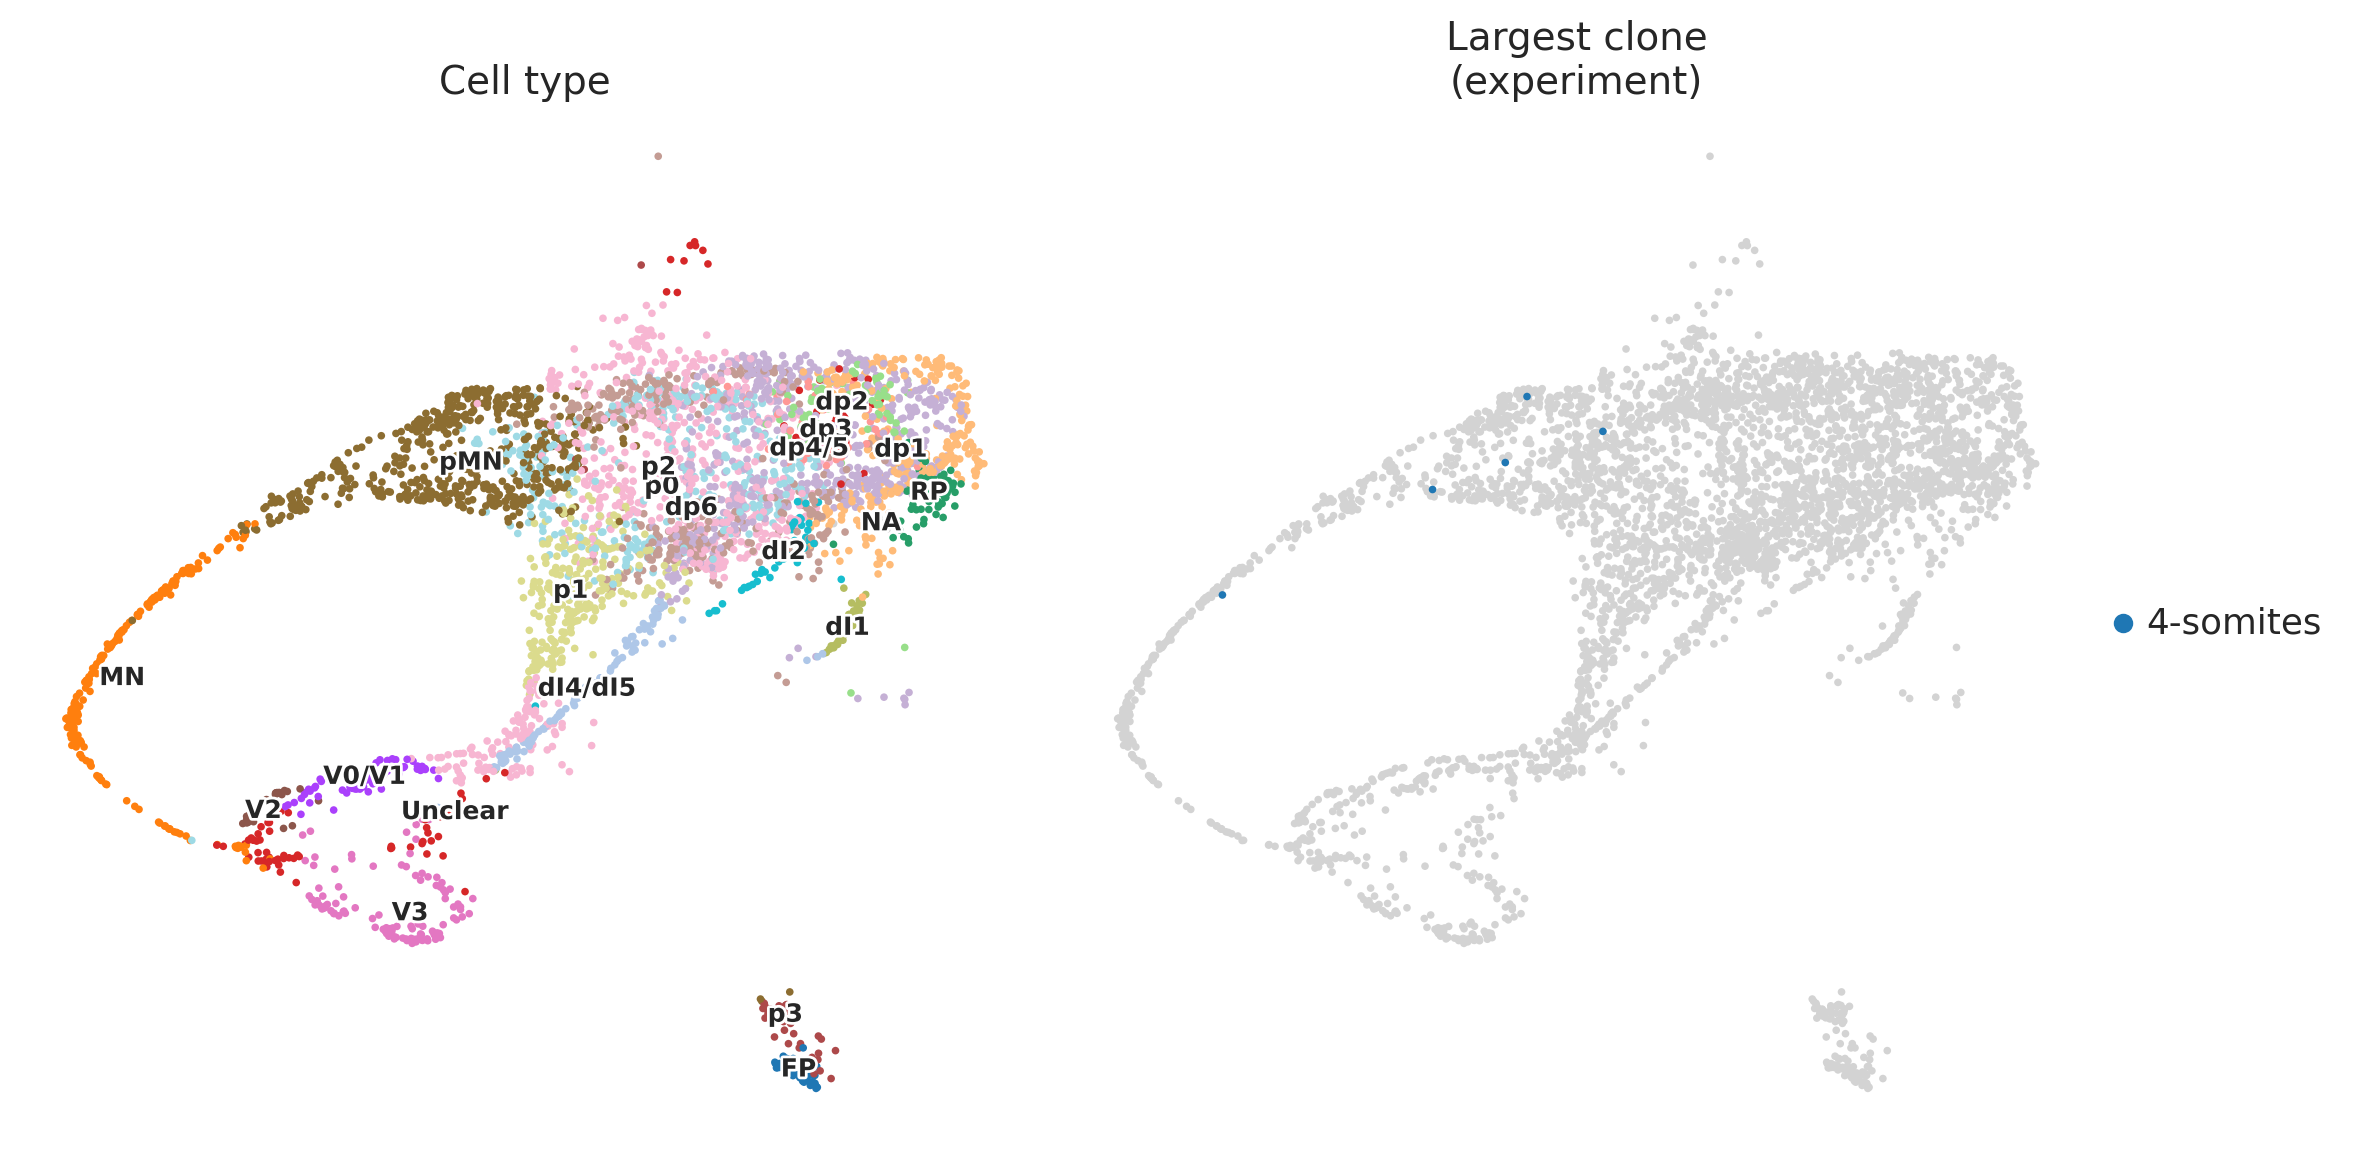

In [15]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))

sc.pl.embedding(
    adata, basis="X_umap",
    color="cell_type",
    frameon=False, title="Cell type",
    legend_loc="on data", legend_fontsize=9, legend_fontoutline=2,
    ax=axes[0], show=False,
)

sl.pl.clone(
    adata,
    clone_col="clone",
    clone_name=adata.obs["clone"].dropna().value_counts().index[0],
    basis="X_umap",
    title="Largest clone",
    kwargs_clone={"color": "experiment"},
    ax=axes[1],
)
fig.tight_layout()

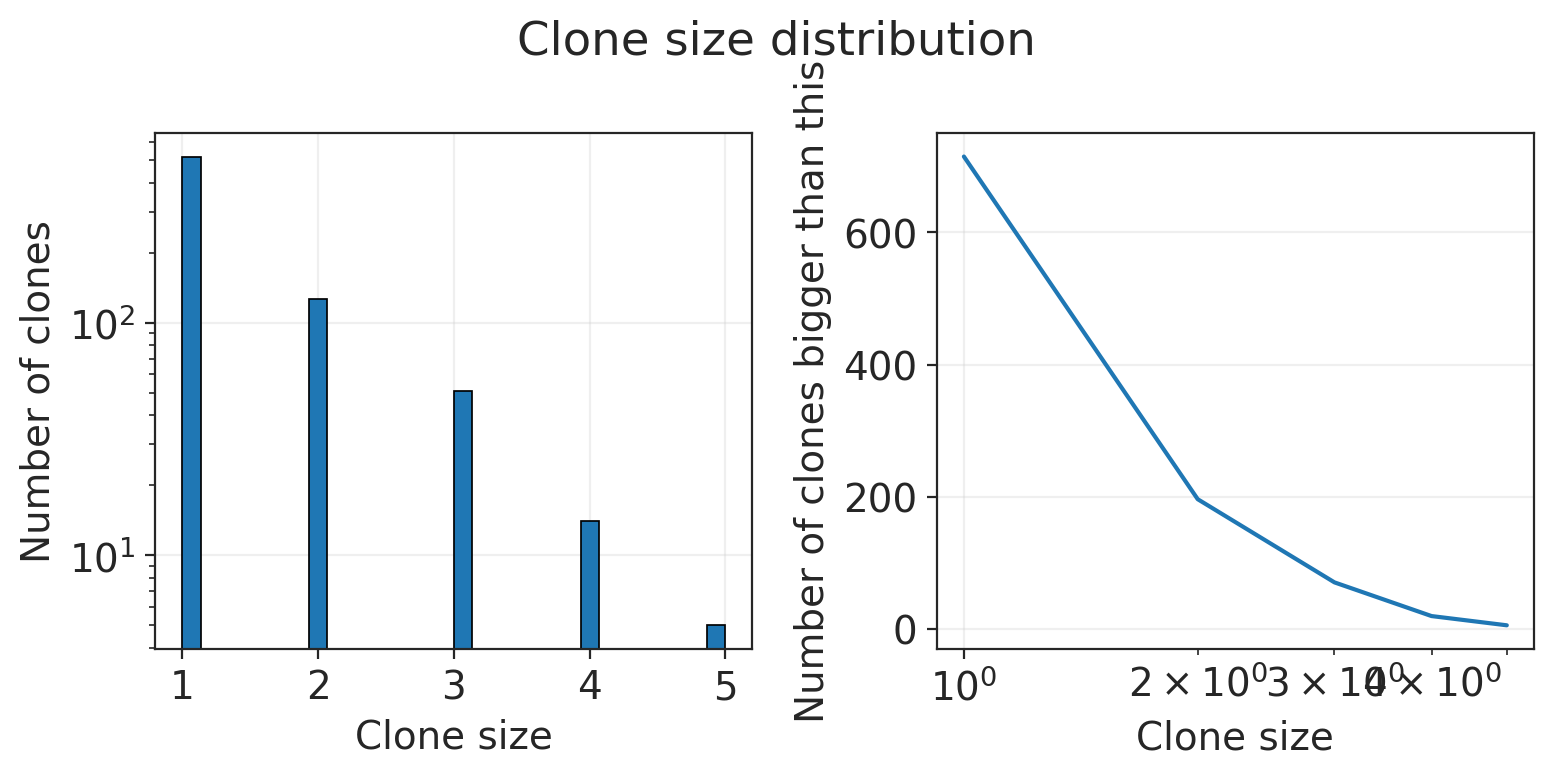

In [16]:
sl.pl.basic_stats(adata, obs_name="clone", title="Clone size distribution")

# Clone2vec

In [17]:
adata_clone2vec = adata[adata.obs["clone"].notna()].copy()

sl.tl.clonal_nn(
    adata_clone2vec,
    obs_name="clone",
    use_rep=scvi_rep,
    min_size=2,
    tqdm_bar=True,
)

100%|██████████| 1010/1010 [00:00<00:00, 1304.05it/s]


In [18]:
clones = sl.tl.clone2vec(
    adata_clone2vec,
    obs_name="clone",
    fill_ct=None,
    device="cpu",
    n_epochs=100,
)

100%|██████████| 100/100 [00:09<00:00, 10.27it/s]
/camp/lab/briscoej/home/users/boeziog/.conda/envs/sclitr_cpu/lib/python3.9/site-packages/anndata/_core/storage.py:85: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/camp/lab/briscoej/home/users/boeziog/.conda/envs/sclitr_cpu/lib/python3.9/site-packages/anndata/_core/storage.py:85: ImplicitModificationWarning: Layer 'frequencies' should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/camp/lab/briscoej/home/users/boeziog/.conda/envs/sclitr_cpu/lib/python3.9/site-packages/anndata/_core/storage.py:85: ImplicitModificationWarning: Layer 'counts' should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)


In [19]:
output_clones_h5ad = os.path.join(
    data_path, "injHH7-collHH18", f"{target_experiment}_clones_clone2vec_trained.h5ad"
)
clones.write_h5ad(output_clones_h5ad)
print(f"Saved to {output_clones_h5ad}")

Saved to /nemo/lab/briscoej/home/users/boeziog/LARRY/Ashley/['1-somite', '4-somites']_clones_clone2vec_trained.h5ad


In [18]:
# Uncomment to reload without rerunning clone2vec
clones = sc.read_h5ad(os.path.join(
    data_path, "injHH7-collHH18",
    "all_clones_clone2vec_trained.h5ad"
))

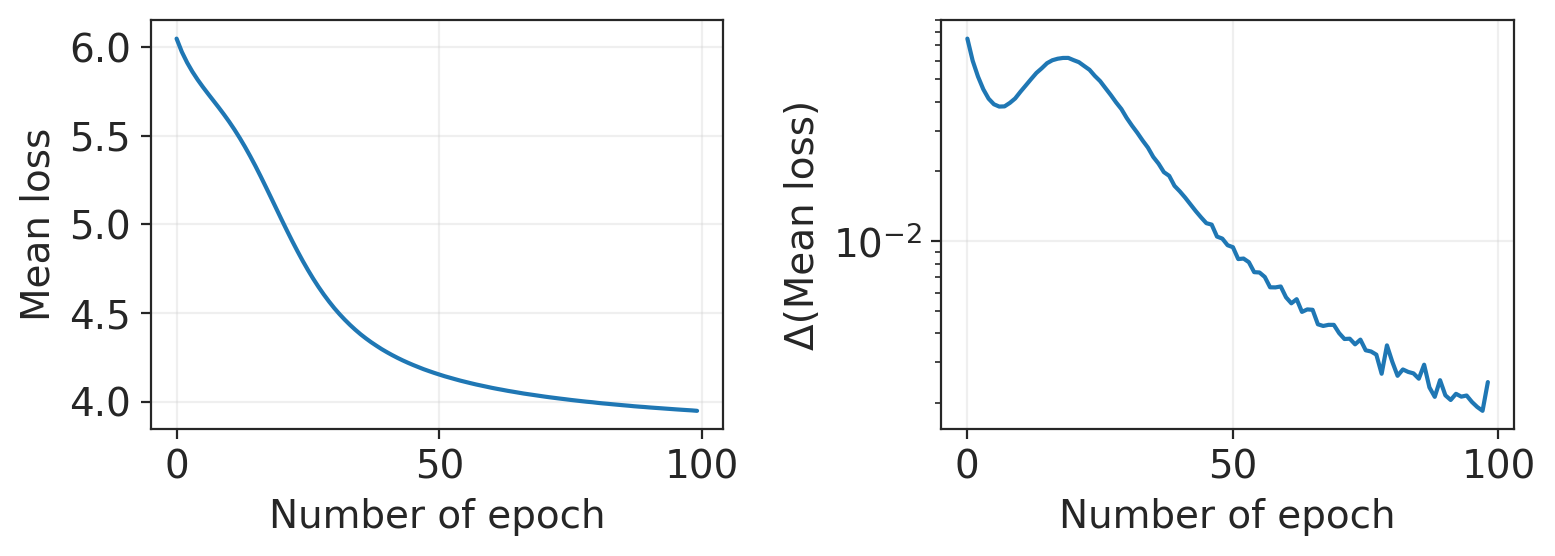

In [19]:
sl.pl.epochs_loss(clones)

/camp/home/boeziog/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/slurm_47551163/ipykernel_3707030/1913583488.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(clones, resolution=0.3)


Saved plot to: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/scLiTr/['1-somite', '4-somites', '7-somites']_clonal_clusters_UMAP_0.3.pdf


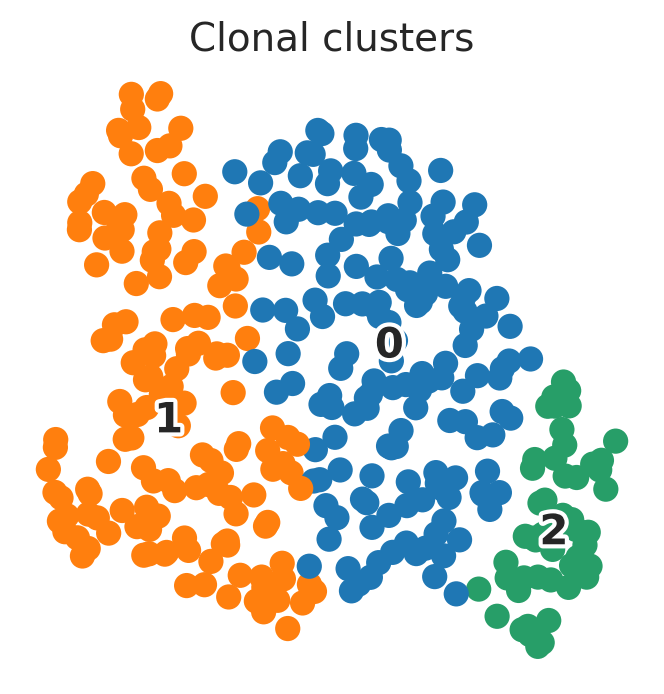

In [20]:
sc.pp.neighbors(clones, use_rep="clone2vec", n_neighbors=15)
sc.tl.umap(clones)
sc.tl.leiden(clones, resolution=0.3)

sc.pl.umap(
    clones, color="leiden", frameon=False,
    title="Clonal clusters",
    legend_loc="on data", legend_fontsize=15, legend_fontoutline=3,
    show=False,
)
save_plot("clonal_clusters_UMAP_0.3")

/tmp/slurm_47551163/ipykernel_3707030/197264250.py:9: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["clonal_cluster_plot"] = adata.obs["clonal_cluster"].replace("NA", np.nan)


Saved plot to: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/scLiTr/['1-somite', '4-somites', '7-somites']_cells_UMAP_and_clonal_clusters_0.3.pdf


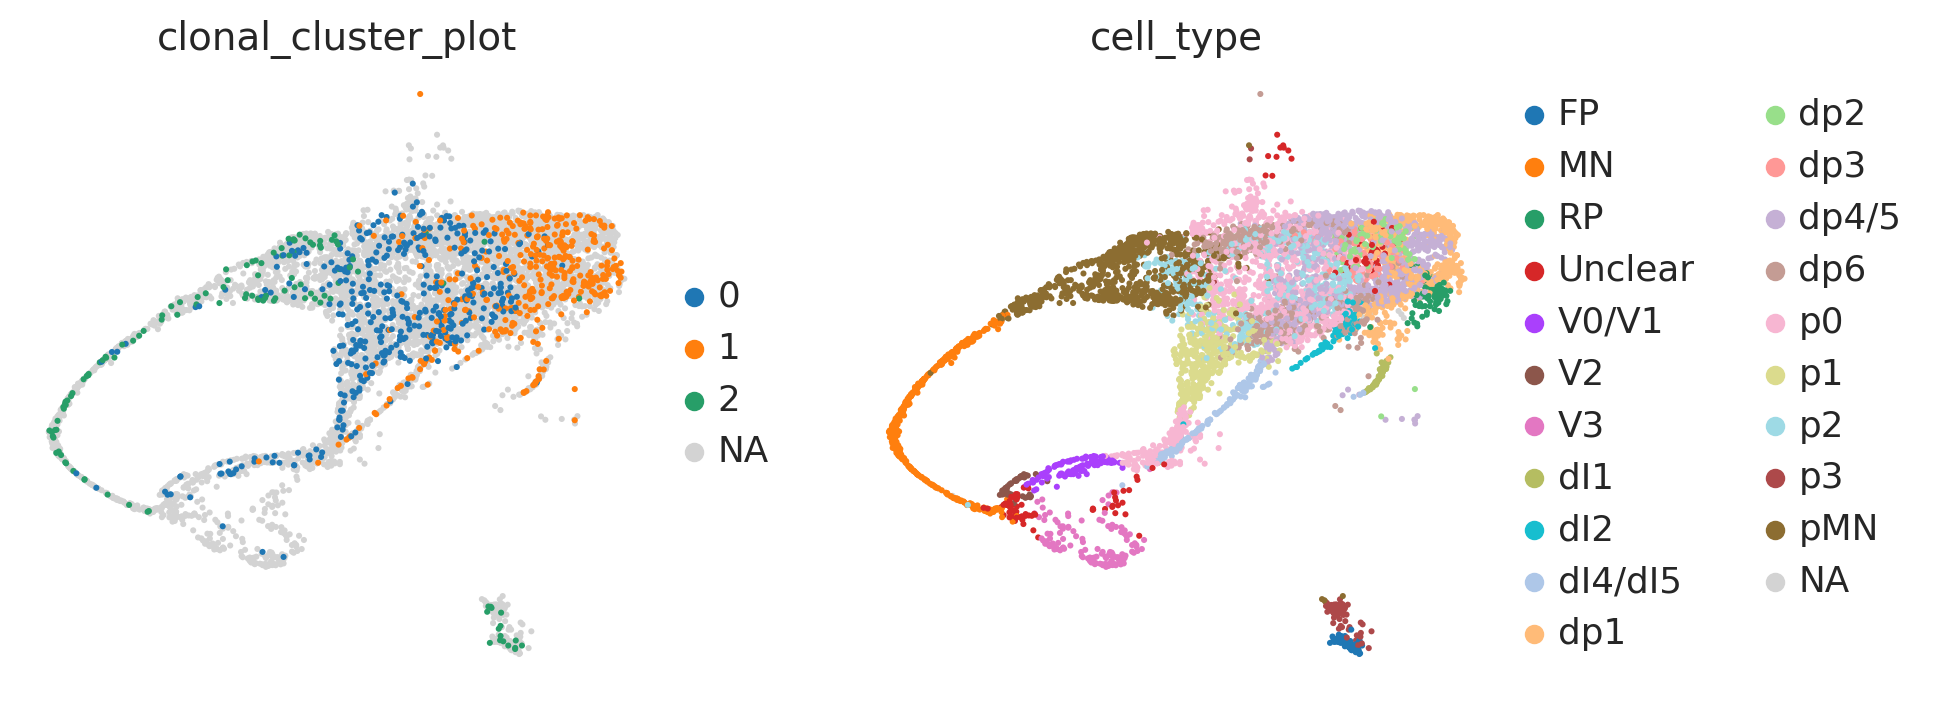

In [21]:
sl.tl.transfer_clonal_annotation(
    adata, clones,
    adata_clone_name="clone",
    adata_obs_name="clonal_cluster",
    clones_obs_name="leiden",
    fill_values="NA",
)

adata.obs["clonal_cluster_plot"] = adata.obs["clonal_cluster"].replace("NA", np.nan)

sc.pl.umap(
    adata, color=["clonal_cluster_plot", "cell_type"],
    frameon=False, ncols=2, show=False,
)
save_plot("cells_UMAP_and_clonal_clusters_0.3")

/tmp/slurm_47551163/ipykernel_3707030/2804714805.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["clonal_cluster"]


Saved plot to: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/scLiTr/['1-somite', '4-somites', '7-somites']_clonal_clusters_density_on_cells_UMAP_0.3.pdf


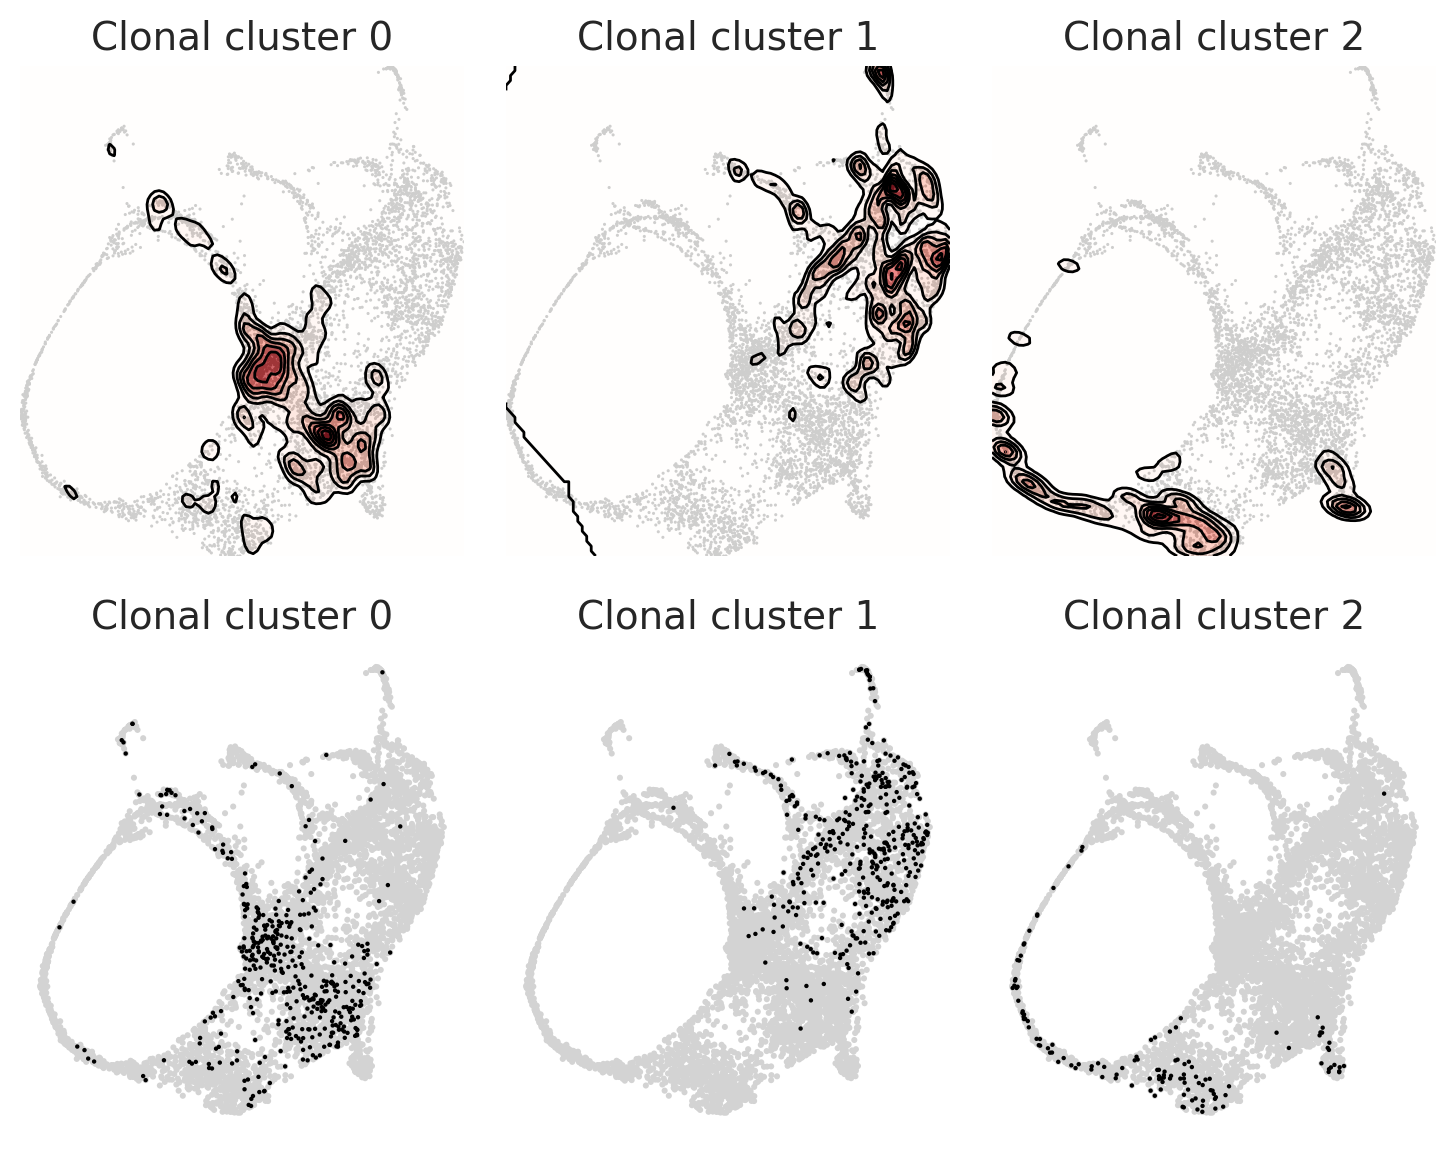

In [22]:
# Slice UMAP to 2D for scLiTr spatial plots
adata.obsm["X_umap_2d"] = adata.obsm["X_umap"][:, [0, 2]]

clusters = sorted(
    adata.obs["clonal_cluster"]
    .replace("NA", np.nan)
    .dropna()
    .unique()
    .astype(str),
    key=lambda x: int(x) if x.isdigit() else x
)
n_clusters = len(clusters)

fig, axes = plt.subplots(nrows=2, ncols=n_clusters, figsize=(2.5 * n_clusters, 6))

for i, clonal_cluster in enumerate(clusters):
    sl.pl.kde(
        adata, basis="X_umap_2d",
        groupby="clonal_cluster", group=clonal_cluster,
        title=f"Clonal cluster {clonal_cluster}",
        ax=axes[0, i],
    )
    sl.pl.clone(
        adata, clone_col="clonal_cluster", clone_name=clonal_cluster,
        basis="X_umap_2d", title=f"Clonal cluster {clonal_cluster}",
        s=10, ax=axes[1, i],
    )

save_plot("clonal_clusters_density_on_cells_UMAP_0.3")
fig.tight_layout()

# Bar plots — clonal cluster composition

Saved plot to: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/scLiTr/['1-somite', '4-somites']_clonal_cluster_barplot_0.3_cell_type.pdf


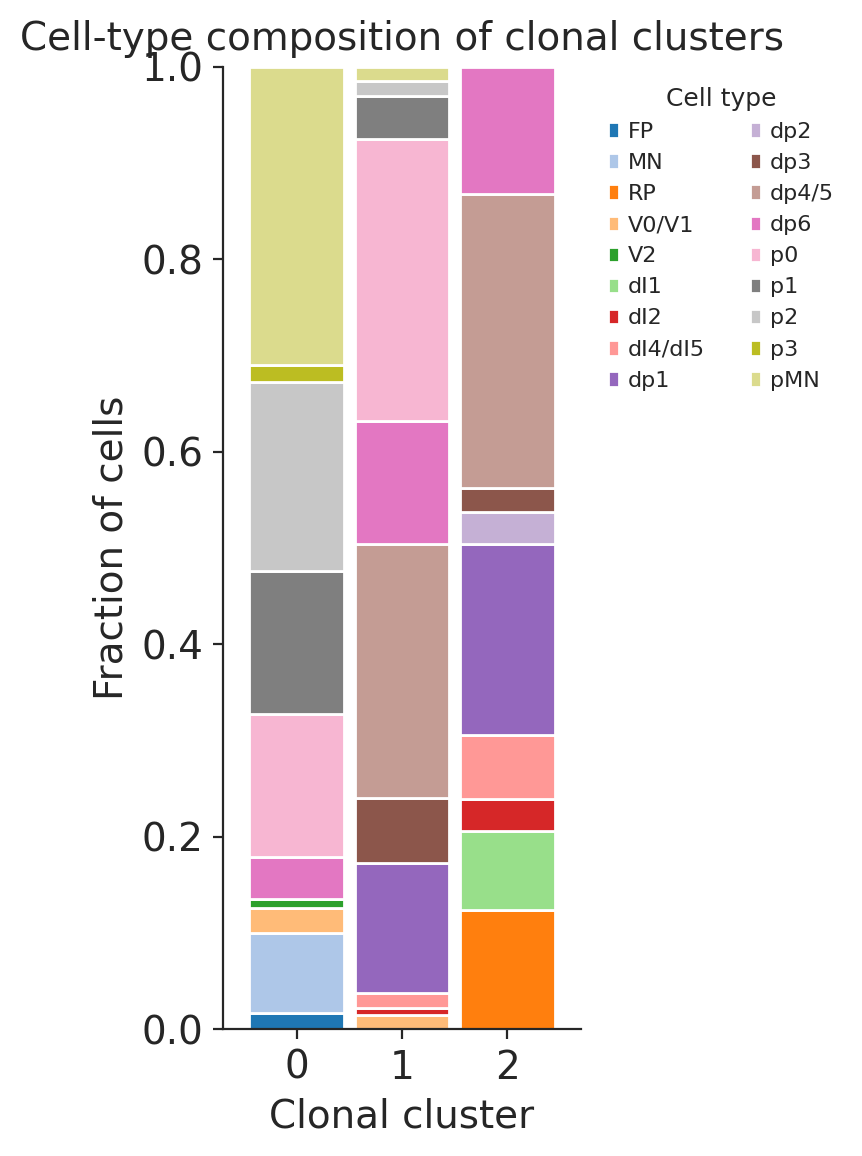

In [35]:
excluded_cell_types = {"Unclear"}

df_plot = adata.obs.loc[
    adata.obs["clonal_cluster"].notna() &
    (adata.obs["clonal_cluster"] != "NA") &
    adata.obs["cell_type"].notna() &
    ~adata.obs["cell_type"].isin(excluded_cell_types),
    ["clonal_cluster", "cell_type"]
].copy()

df_plot["clonal_cluster"] = df_plot["clonal_cluster"].astype(str)

counts = (
    df_plot
    .groupby(["clonal_cluster", "cell_type"], observed=True)
    .size()
    .reset_index(name="n_cells")
)

plot_df = (
    counts
    .groupby(["clonal_cluster", "cell_type"], observed=True)["n_cells"]
    .sum()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
    .unstack(fill_value=0)
)

plot_df = plot_df.loc[plot_df.sum(axis=1) > 0]

palette = (
    sns.color_palette("tab20", 20)
    + sns.color_palette("tab20b", 20)
    + sns.color_palette("tab20c", 20)
)[:plot_df.shape[1]]

fig, ax = plt.subplots(figsize=(1.4 * plot_df.shape[0], 6))
plot_df.plot(kind="bar", stacked=True, ax=ax, color=palette, width=0.9)
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df.index.get_level_values(0).astype(str), rotation=0)
ax.set_ylim(0, 1)
ax.set_ylabel("Fraction of cells")
ax.set_xlabel("Clonal cluster")
ax.set_title("Cell-type composition of clonal clusters")
ax.legend(title="Cell type", bbox_to_anchor=(1.02, 1), loc="upper left",
          frameon=False, fontsize=8, title_fontsize=9, ncol=2)
save_plot("clonal_cluster_barplot_0.3", annotation="cell_type")
sns.despine()
plt.tight_layout()
plt.show()

In [23]:
# ── Edit subdivisions after visual inspection ───────────────────────────────────────────────
lineage_subdivision_map = {
    # Sub_1 — most ventral
    "FP":       "Sub_1",
    "V3":       "Sub_1",
    "p3":       "Sub_1",
    # Sub_2 — ventral (pMN / MN domain)
    "MN":       "Sub_2",
    "pMN":      "Sub_2",
    "p2":       "Sub_2",
    "V2":       "Sub_2",
    # Sub_3 — mid-ventral (p0/p1 domain)
    "p1":       "Sub_3",
    "p0":       "Sub_3",
    "V0/V1":    "Sub_3",
    "dp6":      "Sub_3",
    # Sub_4 — mid-dorsal (dp3–dp5 domain)
    "dp3":      "Sub_4",
    "dp4/5":    "Sub_4",
    "dI4/dI5":  "Sub_4",
    # Sub_5 — most dorsal
    "RP":       "Sub_5",
    "dI1":      "Sub_5",
    "dI2":      "Sub_5",
    "dp1":      "Sub_5",
    "dp2":      "Sub_5",
}


# lineage_subdivision_map = {
#     # A — most ventral
#     "FP":       "Sub_A",
#     "V3":       "Sub_A",
#     "p3":       "Sub_A",
#     "MN":       "Sub_A",
#     "pMN":      "Sub_A",

#     # B — mid-ventral (p0/p1 domain)
#     "p2":       "Sub_B",
#     "V2":       "Sub_B",
#     "p1":       "Sub_B",
#     "p0":       "Sub_B",
#     "V0/V1":    "Sub_B",
#     "dp6":      "Sub_B",
#     # C — most-dorsal (dp3–dp5 domain)
#     "dp3":      "Sub_C",
#     "dp4/5":    "Sub_C",
#     "dI4/dI5":  "Sub_C",
#     "RP":       "Sub_C",
#     "dI1":      "Sub_C",
#     "dI2":      "Sub_C",
#     "dp1":      "Sub_C",
#     "dp2":      "Sub_C",
# }

adata.obs["lineage_subdivision"] = adata.obs["cell_type"].map(lineage_subdivision_map)
print(adata.obs["lineage_subdivision"].value_counts(dropna=False))

lineage_subdivision
Sub_3    2108
Sub_2    1725
Sub_4    1178
Sub_5     815
Sub_1     295
NaN       142
Name: count, dtype: int64


Saved plot to: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/scLiTr/['1-somite', '4-somites', '7-somites']_clonal_cluster_barplot_lineage_subdivisions_original.pdf


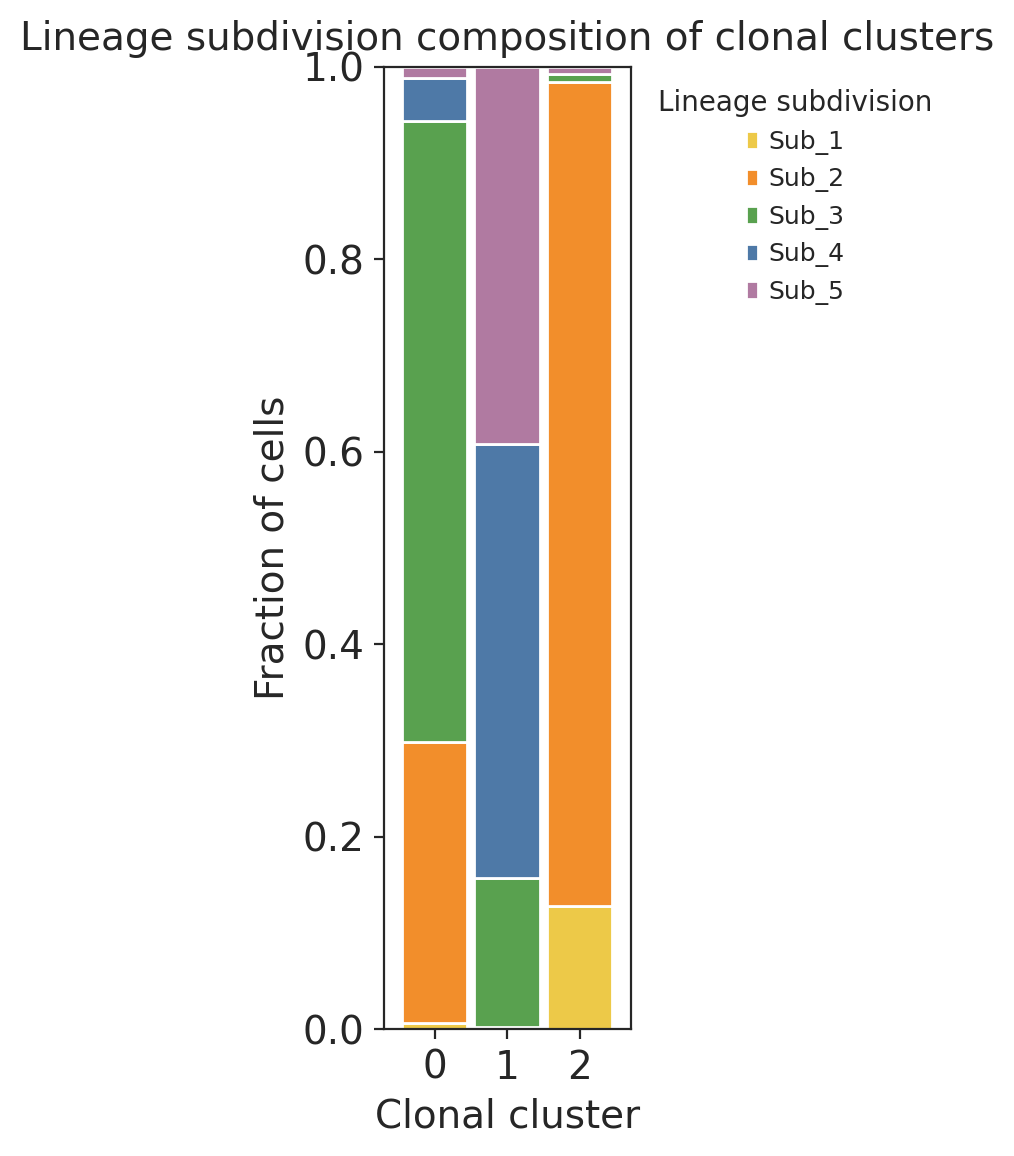

In [25]:
excluded_cell_types = {"Unclear"}

df_plot = adata.obs.loc[
    adata.obs["clonal_cluster"].notna() &
    (adata.obs["clonal_cluster"] != "NA") &
    ~adata.obs["cell_type"].isin(excluded_cell_types) &
    adata.obs["lineage_subdivision"].notna(),
    ["clonal_cluster", "lineage_subdivision"]
].copy()

counts = (
    df_plot
    .groupby(["clonal_cluster", "lineage_subdivision"], observed=True)
    .size()
    .reset_index(name="n_cells")
)

plot_df = (
    counts
    .pivot_table(
        index="clonal_cluster", columns="lineage_subdivision",
        values="n_cells", fill_value=0, observed=True,
    )
)
plot_df = plot_df.div(plot_df.sum(axis=1), axis=0)

#Palette subdivisions 1-5
palette = {
    "Sub_1": "#EDC948",
    "Sub_2": "#F28E2B",
    "Sub_3": "#59A14F",
    "Sub_4": "#4E79A7",
    "Sub_5": "#B07AA1",
}

# #Palette compartments ABC
# palette = {
#     "Sub_A": "#EDC948",
#     "Sub_B": "#59A14F",
#     "Sub_C": "#B07AA1",
# }

# Reorder after inspecting bar plot above
cluster_order = sorted(plot_df.index.astype(str).tolist(), key=lambda x: int(x) if x.isdigit() else x)
plot_df = plot_df.reindex(cluster_order).dropna(how="all")

fig, ax = plt.subplots(figsize=(1.3 * plot_df.shape[0], 6))
plot_df.plot(
    kind="bar", stacked=True, ax=ax,
    color=[palette[c] for c in plot_df.columns], width=0.9,
)
ax.set_ylim(0, 1)
ax.set_ylabel("Fraction of cells")
ax.set_xlabel("Clonal cluster")
ax.set_title("Lineage subdivision composition of clonal clusters")
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df.index.astype(str), rotation=0)
ax.legend(title="Lineage subdivision", bbox_to_anchor=(1.02, 1), loc="upper left",
          frameon=False, fontsize=9, title_fontsize=10)
save_plot("clonal_cluster_barplot", annotation="lineage_subdivisions_original")
plt.tight_layout()
plt.show()

Saved plot to: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/scLiTr/1-somite_clonal_cluster_piechart_lineage_subdivision.pdf


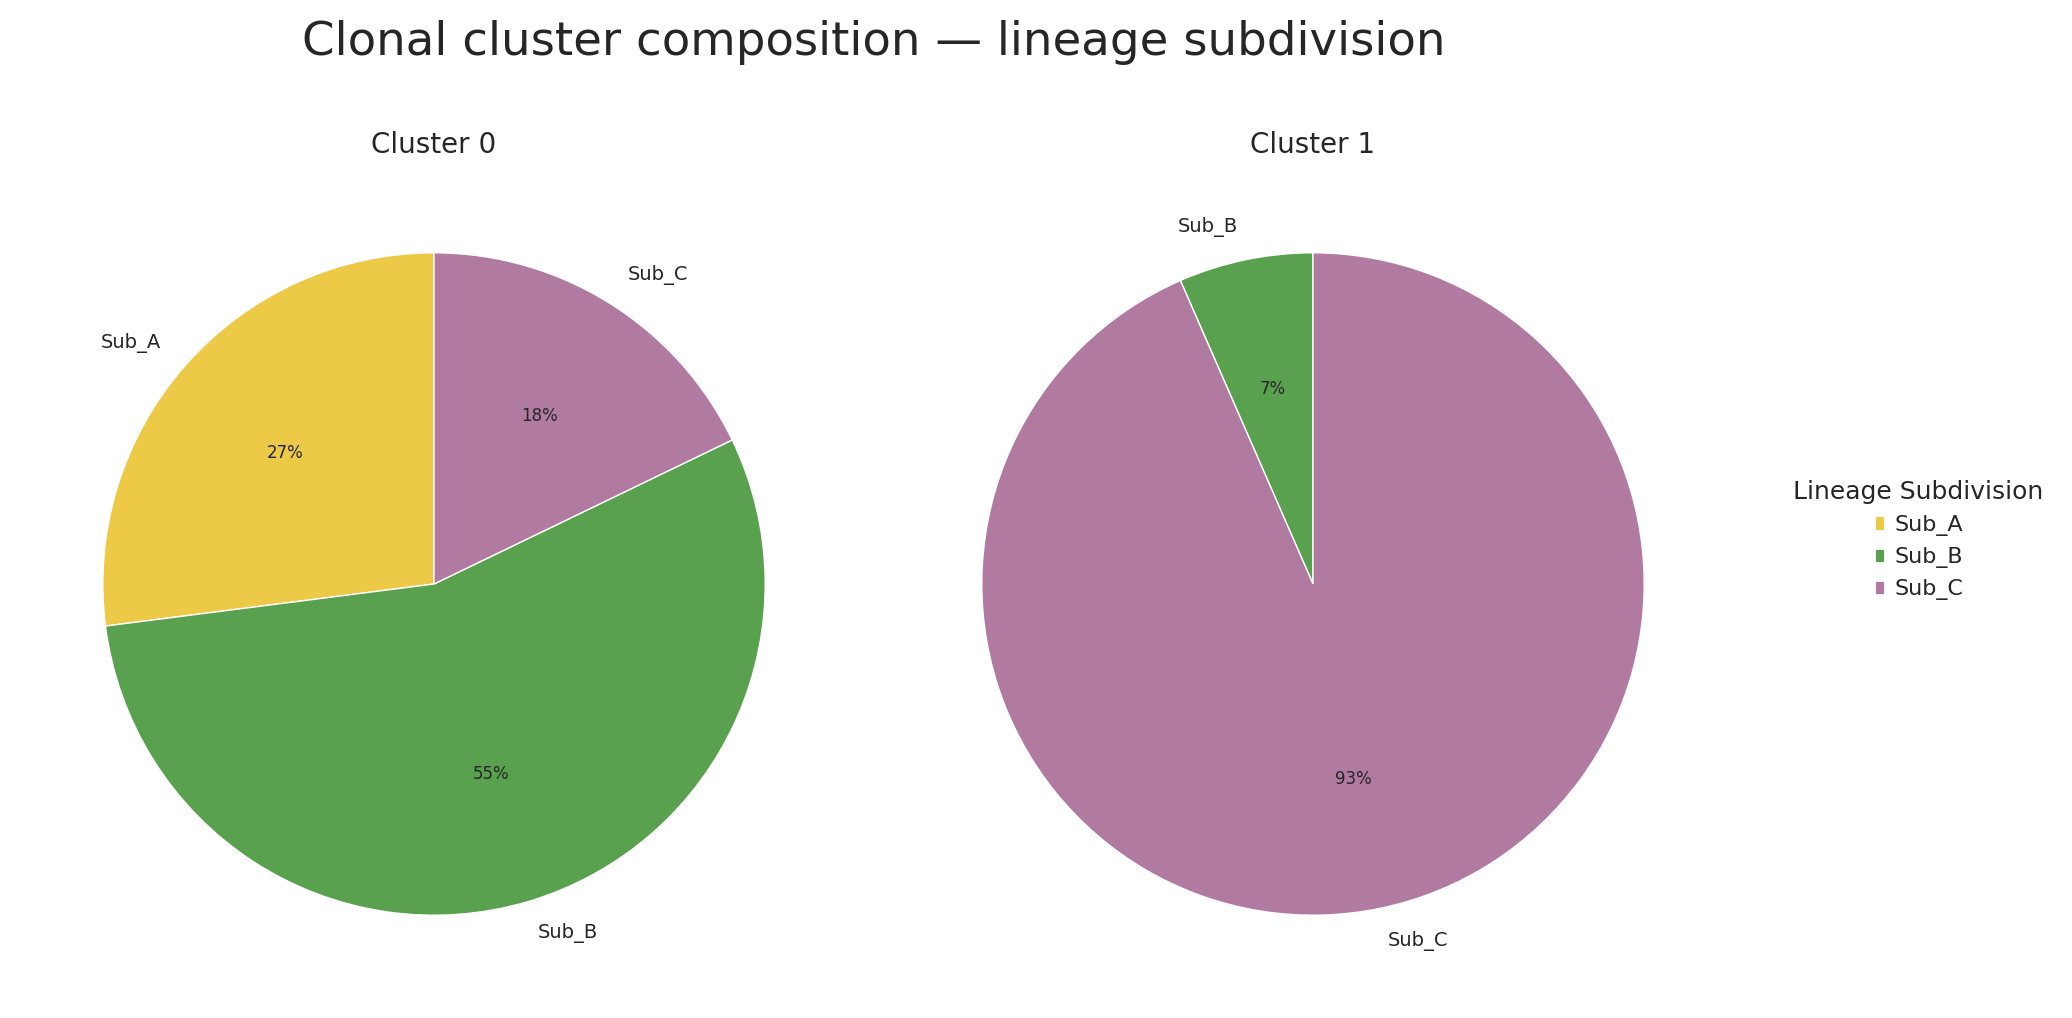

In [164]:
from matplotlib.patches import Patch

# ── TOGGLE ──────────────────────────────────────────────────────────────────
ANNOTATION = "cell_type"
ANNOTATION = "lineage_subdivision"

excluded_cell_types = {"Unclear"}

# ── Rebuild data from adata.obs ──────────────────────────────────────────────
df_pie = adata.obs.loc[
    adata.obs["clonal_cluster"].notna() &
    (adata.obs["clonal_cluster"] != "NA") &
    adata.obs[ANNOTATION].notna() &
    ~adata.obs[ANNOTATION].isin(excluded_cell_types),
    ["clonal_cluster", ANNOTATION]
].copy()
df_pie["clonal_cluster"] = df_pie["clonal_cluster"].astype(str)

counts_pie = df_pie.groupby(["clonal_cluster", ANNOTATION], observed=True).size().reset_index(name="n")
plot_pie = counts_pie.pivot_table(index="clonal_cluster", columns=ANNOTATION, values="n", fill_value=0)
plot_pie = plot_pie.div(plot_pie.sum(axis=1), axis=0)

# ── Cluster order ─────────────────────────────────────────────────────────────
cluster_order_pie = sorted(
    plot_pie.index.astype(str).tolist(),
    key=lambda x: int(x) if x.isdigit() else x
)
plot_pie = plot_pie.reindex(cluster_order_pie)

# ── Colours ───────────────────────────────────────────────────────────────────
if ANNOTATION == "lineage_subdivision":
    color_map = {
    "Sub_A": "#EDC948",
    "Sub_B": "#59A14F",
    "Sub_C": "#B07AA1",
    }
else:
    labels_list = plot_pie.columns.tolist()
    pie_palette = (
        sns.color_palette("tab20", 20)
        + sns.color_palette("tab20b", 20)
        + sns.color_palette("tab20c", 20)
    )[:len(labels_list)]
    color_map = dict(zip(labels_list, pie_palette))

# ── Plot ──────────────────────────────────────────────────────────────────────
n = len(cluster_order_pie)
fig, axes = plt.subplots(1, n, figsize=(3.5 * n + 2, 5))
if n == 1:
    axes = [axes]

for ax, cluster in zip(axes, cluster_order_pie):
    row    = plot_pie.loc[cluster]
    row    = row[row > 0]
    colors = [color_map[ct] for ct in row.index]

    wedges, texts, autotexts = ax.pie(
        row.values,
        labels=[ct if v > 0.05 else "" for ct, v in zip(row.index, row.values)],
        colors=colors,
        autopct=lambda p: f"{p:.0f}%" if p > 5 else "",
        pctdistance=0.6,
        startangle=90,
        wedgeprops={"linewidth": 0.5, "edgecolor": "white"},
    )
    for t in texts:
        t.set_fontsize(7)
    for t in autotexts:
        t.set_fontsize(6)
    ax.set_title(f"Cluster {cluster}", fontsize=10)

# ── Legend (all categories) ───────────────────────────────────────────────────
legend_handles = [Patch(facecolor=color_map[ct], label=ct) for ct in plot_pie.columns if ct in color_map]
fig.legend(
    handles=legend_handles,
    title=ANNOTATION.replace("_", " ").title(),
    bbox_to_anchor=(1.0, 0.5),
    loc="center left",
    frameon=False,
    fontsize=8,
    title_fontsize=9,
)

plt.suptitle(f"Clonal cluster composition — {ANNOTATION.replace('_', ' ')}", y=1.02)
plt.tight_layout()
save_plot("clonal_cluster_piechart", annotation=ANNOTATION)
plt.show()


# Heatmap

/tmp/slurm_47551163/ipykernel_3707030/815004002.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts


Saved plot to: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/scLiTr/['1-somite', '4-somites', '7-somites']_clonal_cluster_heatmap_OrRd_0.6_lineage_subdivision.pdf


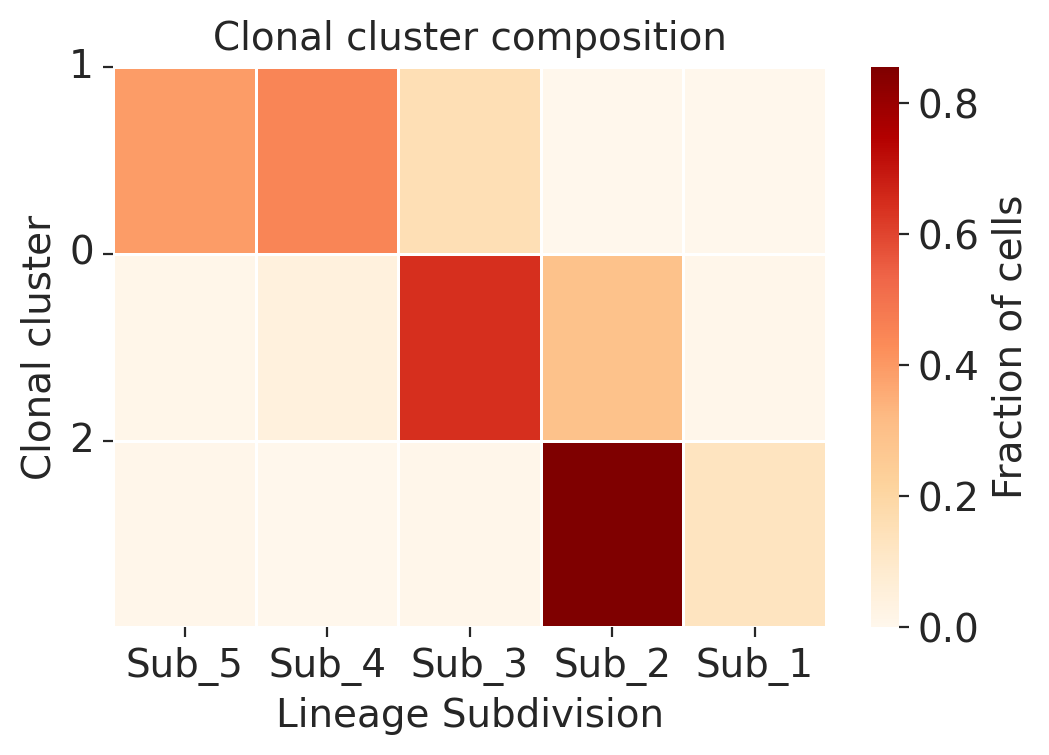

In [27]:
# ── USER CHOICES ────────────────────────────────────────────────────────────────────────────────
ANNOTATION = "lineage_subdivision"
# ANNOTATION = "cell_type"

# Fill in after running bar plots above
# cluster_order = sorted(
#     adata.obs["clonal_cluster"].replace("NA", np.nan).dropna().unique().astype(str),
#     key=lambda x: int(x) if x.isdigit() else x,
# )

cluster_order = [ "1", "0", "2"]  # your preferred order

cell_type_order = [
    "RP", "dI1", "dI2", "dp1", "dp2",
    "dp3", "dp3/4", "dp4/5", "dp5", "dI4/6", "dI5",
    "dp6", "dp6/dp5", "p0/dp6",
    "p0", "p0/p1", "V0/V1", "p1", "p1/p2",
    "p2", "V2",
    "pMN", "pMN/p2", "pMN/p3", "MN",
    "p3", "V3", "FP",
]

lineage_sub_order = ["Sub_5", "Sub_4", "Sub_3", "Sub_2", "Sub_1"]
# lineage_sub_order = ["Sub_C", "Sub_B", "Sub_A"]
excluded_cell_types = {"Unclear"}

# ── Subset ────────────────────────────────────────────────────────────────────────────
df = adata.obs.loc[
    adata.obs["clonal_cluster"].notna() &
    (adata.obs["clonal_cluster"] != "NA"),
    ["clonal_cluster", ANNOTATION]
].copy()
if ANNOTATION == "cell_type":
    df = df[~df["cell_type"].isin(excluded_cell_types)]

# ── Count + normalize ──────────────────────────────────────────────────────────────
counts = (
    df
    .groupby(["clonal_cluster", ANNOTATION], observed=True)
    .size()
    .reset_index(name="n_cells")
)

heatmap_df = (
    counts
    .groupby(["clonal_cluster", ANNOTATION], observed=True)["n_cells"]
    .sum()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
    .unstack(fill_value=0)
)

heatmap_df = heatmap_df.loc[[c for c in cluster_order if c in heatmap_df.index]]

if ANNOTATION == "cell_type":
    heatmap_df = heatmap_df.reindex(
        columns=[ct for ct in cell_type_order if ct in heatmap_df.columns], fill_value=0
    )
    vmax = 0.4
elif ANNOTATION == "lineage_subdivision":
    heatmap_df = heatmap_df.reindex(
        columns=[s for s in lineage_sub_order if s in heatmap_df.columns], fill_value=0
    )
    vmax = None

# ── Plot ───────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(0.5 * heatmap_df.shape[1] + 3, 4))
sns.heatmap(
    heatmap_df, vmax=vmax, cmap="OrRd",
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Fraction of cells"},
)
ax = plt.gca()
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index.get_level_values(0).astype(str), rotation=0)
plt.xlabel(ANNOTATION.replace("_", " ").title())
plt.ylabel("Clonal cluster")
plt.title("Clonal cluster composition")
save_plot("clonal_cluster_heatmap_OrRd_0.6", annotation=ANNOTATION)
plt.tight_layout()
plt.show()

# Fate commitment predictors (SHAP + clone2vec)

In [ ]:
progenitors = [
    "RP", "FP",
    "dp1", "dp2", "dp3", "dp3/4", "dp4/5", "dp5",
    "dp6", "dp6/dp5", "p0/dp6",
    "p0", "p0/p1", "p1", "p1/p2", "p2",
    "pMN", "pMN/p2", "pMN/p3", "p3",
]

adata.obs["early_state"] = np.where(
    adata.obs["cell_type"].isin(progenitors),
    "Early",
    "Other",
)
print(adata.obs["early_state"].value_counts())

adata_clonal = adata[adata.obs["clone"].notna()].copy()
print("\nClonal cells early_state:\n", adata_clonal.obs["early_state"].value_counts())

In [ ]:
shapdata_c2v = sl.tl.predict_c2v(
    adata_clonal, clones,
    clone_col="clone",
    ct_col="early_state",
    use_gpu=False,
    verbose=False,
    limit_ct="Early",
    use_ct=False,
    pseudobulk=True,
)

In [ ]:
shap_path = os.path.join(
    data_path, "injHH7-collHH18_LARRY", "data",
    f"{target_experiment}_shapdata_c2v.h5ad"
)
shapdata_c2v.write_h5ad(shap_path)
print(f"Saved to {shap_path}")

In [ ]:
# shapdata_c2v = sc.read_h5ad(shap_path)

In [ ]:
shapdata_c2v.var["average_shap"] = (
    shapdata_c2v.layers["shap"].mean(axis=0).A[0]
)
shapdata_c2v.var["average_shap_normalized"] = (
    shapdata_c2v.var["average_shap"] /
    shapdata_c2v.var["average_shap"].max()
)

top_genes = shapdata_c2v.var.sort_values("average_shap", ascending=False)
print(top_genes.head(20))

In [ ]:
all_top_genes = []
for dim in range(10):
    layer_name = f"shap_c2v{dim}"
    if layer_name not in shapdata_c2v.layers:
        continue
    scores = np.array(shapdata_c2v.layers[layer_name].mean(axis=0)).flatten()
    gene_df = shapdata_c2v.var.copy()
    gene_df["score"] = scores
    gene_df["dimension"] = dim
    gene_df["gene"] = gene_df.index
    top_df = gene_df.sort_values("score", ascending=False).head(20)
    all_top_genes.append(top_df[["dimension", "gene", "score"]])

all_top_genes_df = pd.concat(all_top_genes, ignore_index=True)

csv_out = os.path.join(
    data_path, "injHH7-collHH18_LARRY", "data",
    f"{target_experiment}_top_genes_per_clone2vec_dimension.csv"
)
all_top_genes_df.to_csv(csv_out, index=False)
print(f"Saved to {csv_out}")
all_top_genes_df.head(30)

In [ ]:
c2v_df = pd.DataFrame(clones.obsm["clone2vec"], index=clones.obs_names)
c2v_df["cluster"] = clones.obs["leiden"]
cluster_means = c2v_df.groupby("cluster", observed=True).mean()

sns.heatmap(cluster_means, cmap="RdBu_r", center=0)
plt.ylabel("Clonal clusters")
plt.xlabel("Clone2vec dimension")
plt.title("Clonal clusters vs clone2vec dimensions")
save_plot("clonal_cluster_vs_dimension")
plt.tight_layout()
plt.show()